In [ ]:
# Interpretations written in the context of varying environments, but can be used for Parkinson's mouse, just make sure to change the interpretation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import h5py
import os
import re
from collections import Counter
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon
from scipy.spatial.distance import cosine

In [2]:
# CHANGE HERE
filename = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\042425_2lc\week8-10-12-14-18\Cluster_detail_results.csv'

In [3]:
# Preprocessing

clusters_data = pd.read_csv( filename )
clusters_data = clusters_data.dropna()

unique_weeks = sorted(clusters_data["Week_Number"].unique())
week_map = {week: i+1 for i, week in enumerate(unique_weeks)}

clusters_data["Week_Number"] = clusters_data["Week_Number"].replace(week_map)

clusters_data = clusters_data.rename(columns={ 'Cluster' : 'cluster'})
clusters_data = clusters_data.rename(columns={ 'Week_Number': 'stage'})

n_clusters = int(clusters_data['cluster'].max()) + 1

clusters_data

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,...,Feature24,Feature25,Feature26,Feature27,Feature28,Feature29,Feature30,Timestamp,cluster,stage
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.000000,0.500000,0.500000,0.000000,0.0,0.866667,0.133333,8414.3922,1,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.000000,0.383333,0.616667,0.000000,0.0,0.733333,0.266667,8414.6932,1,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.000000,0.516667,0.483333,0.000000,0.0,0.883333,0.116667,8414.9927,1,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.000000,0.600000,0.400000,0.000000,0.0,0.916667,0.083333,8415.2930,1,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.116667,0.566667,0.166667,0.000000,0.0,0.466667,0.533333,8415.5933,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.083333,0.483333,0.416667,0.016667,0.0,0.066667,0.933333,49786.8398,27,5
120819,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.066667,0.350000,0.400000,0.183333,0.0,0.000000,1.000000,49787.2048,27,5
120820,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.4,...,0.033333,0.483333,0.250000,0.133333,0.0,0.000000,1.000000,49787.5498,87,5
120821,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.183333,0.150000,0.333333,0.216667,0.0,0.000000,1.000000,49787.8948,50,5


In [4]:
# Definitions

# Context Specificity Index
def compute_csi(stage_clusters, ref_clusters):
    return (len(stage_clusters) - len(ref_clusters)) / (len(stage_clusters) + len(ref_clusters))

# Novelty index: fraction of clusters unique. 
def novelty_index(stage_clusters, ref_clusters):
    return len(stage_clusters - ref_clusters) / len(ref_clusters)


def plot_csi_novelty( csi_plot_stages , plot_csi , plot_novelty ):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.barplot(x=csi_plot_stages, y=plot_csi, ax=axes[0], color='lightblue')
    axes[0].set_title("Context Specificity Index (vs Stage 1)")
    axes[0].set_ylabel("CSI")
    axes[0].set_xlabel("Stage")

    sns.barplot(x=csi_plot_stages, y=plot_novelty, ax=axes[1], color='salmon')
    axes[1].set_title("Novelty Index (vs Stage 1)")
    axes[1].set_ylabel("Novelty")
    axes[1].set_xlabel("Stage")

    plt.tight_layout()
    plt.show()

# Shannon Entropy
def compute_shannon_entropy(df):
    p = df['cluster'].value_counts(normalize=True)
    return entropy(p, base=2)

def plot_rep_entropy( stage_labels, rep_sizes, entropies ):
    fig, axs = plt.subplots(1, 2, figsize=(15,4))

    sns.barplot(x=stage_labels, y=rep_sizes, ax=axs[0], palette="Blues_d")
    axs[0].set(title="Repertoire Size",
            ylabel="Unique Clusters",
            xlabel="Stage")

    sns.barplot(x=stage_labels, y=entropies, ax=axs[1], palette="Greens_d")
    axs[1].set(title="Shannon Entropy",
            ylabel="Entropy (bits)",
            xlabel="Stage")

    plt.tight_layout()
    plt.show()

# Transition Distribution
def get_transition_distribution(df, cluster_to_idx, n_clusters):
    clusters = df["cluster"].tolist()
    transitions = list(zip(clusters[:-1], clusters[1:]))
    counts = Counter(
        (cluster_to_idx[a], cluster_to_idx[b]) 
        for a, b in transitions
        if a in cluster_to_idx and b in cluster_to_idx
    )

    vec = np.zeros(n_clusters * n_clusters, dtype=float)
    for (from_idx, to_idx), c in counts.items():
        idx = from_idx * n_clusters + to_idx
        vec[idx] = c

    return vec / vec.sum() if vec.sum() > 0 else vec


def plot_similarities( df_trans ):
    fig, ax1 = plt.subplots(figsize=(6, 4))

    plot_df = df_trans.melt( id_vars="Stage", var_name="Metric", value_name="Value")

    sns.barplot( data=plot_df, x="Stage", y="Value", hue="Metric", palette="viridis", ax=ax1 )

    ax1.set( title="Transition Reorganization vs Stage 1",  ylabel="Similarity / Divergence", xlabel="Stage" )
    plt.axhline(1, color="gray", ls="--", lw=0.7)
    plt.tight_layout()
    plt.show()

def extract_ngrams_with_counts(df, n=2, exclude_repeats=False, collapse_repeats=False):
    clusters = df['cluster'].tolist()
    
    if collapse_repeats:
        clusters = [v for i, v in enumerate(clusters) if i == 0 or v != clusters[i-1]]

    ngrams = []
    for i in range(len(clusters) - n + 1):
        ng = tuple(clusters[i:i+n])
        # Skip ngrams like (5,5,5) if exclude_repeats=True
        if exclude_repeats and any(ng[j] == ng[j+1] for j in range(n-1)):
            continue
        ngrams.append(ng)

    c = Counter(ngrams)
    return set(c.keys()), c

def analyze_sequence_diversity_by_stages(dfs, n=2, exclude_repeats=False):
    ngram_sets, count_dicts = zip(*[
        extract_ngrams_with_counts(df, n=n, exclude_repeats=exclude_repeats, collapse_repeats=True)
        for df in dfs
    ])
    
    base = ngram_sets[0]   # Stage 1 is reference

    results = []
    for i, s in enumerate(ngram_sets):
        results.append({
            "Stage": f"Stage {i+1}",
            "Unique n-grams": len(s),
            "Shared w/ Stage 1": len(base & s),
            "New (vs Stage 1)": len(s - base),
            "Lost (vs Stage 1)": len(base - s)
        })
    return pd.DataFrame(results), count_dicts

def plot_sequence_diversity( ngram_results ):
    plt.figure(figsize=(7,5))

    melted = ngram_results.melt(
        id_vars='Stage',
        value_vars=['Unique n-grams', 'Shared w/ Stage 1', 'New (vs Stage 1)', 'Lost (vs Stage 1)'],
        var_name='Metric',
        value_name='Value'
    )

    sns.barplot(
        data=melted,
        x='Stage',
        y='Value',
        hue='Metric',
        palette='coolwarm'
    )

    plt.title('N-gram Diversity and Overlap (vs Stage 1)')
    plt.ylabel('Count')
    plt.xlabel('Stage')
    plt.legend(title='')
    plt.tight_layout()
    plt.show()

def plot_top_ngrams_stagewise(count_dicts, top_n=5, n=3):
    fig, axes = plt.subplots(len(count_dicts), 1, figsize=(10, 2.5 * len(count_dicts)))
    if len(count_dicts) == 1:
        axes = [axes]

    for i, (counts, ax) in enumerate(zip(count_dicts, axes)):
        top = counts.most_common(top_n)
        if not top:
            continue

        labels, vals = zip(*top)
        labels = ['-'.join(map(str, l)) for l in labels]

        ax.bar(range(len(labels)), vals, color='skyblue')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_title(f"Stage {i+1} – Top {top_n} {n}-grams")
        ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Transition entropy = Shannon entropy but for transition probabilities. Calculated as Htrans = -∑ij [p(i -> j )]log[p(i -> j )]
def compute_transition_entropy( df ):
    df = df.copy()
    df['next_cluster'] = df['cluster'].shift(-1)
    df = df.dropna(subset=['next_cluster'])
    transition_counts = df.groupby(['cluster', 'next_cluster']).size().unstack(fill_value=0)
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)
    transition_entropy_per_cluster = transition_probs.apply(lambda row: entropy(row, base=2), axis=1)
    return transition_entropy_per_cluster.mean()

# Calculate Markov entropy, which tells us how predictable the next behavior is, given the current one. Low Markov entropy means that certain transitions occur repeatedly, and the pattern of behavior is more predictable. Entropy should increase as the arenas get more complex. 
# More accurate representation than Shannon entropy for transitions because it accounts for how often each state is visited. "Actual behavioral predictability"

def compute_markov_entropy( df ):
    clusters = df['cluster'].tolist()
    
    transitions = list(zip(clusters[:-1], clusters[1:]))
    transition_counts = Counter(transitions)
    
    outgoing_counts = {}
    for (from_c, to_c), count in transition_counts.items():
        outgoing_counts.setdefault(from_c, 0)
        outgoing_counts[from_c] += count
    
    total_entropy = 0
    total_transitions = sum(transition_counts.values())

    for (from_c, to_c), count in transition_counts.items():
        p_conditional = count / outgoing_counts[from_c]  
        weighted_entropy = (count / total_transitions) * (-np.log2(p_conditional))
        total_entropy += weighted_entropy

    return total_entropy

def plot_entropy_gap( entropy_gaps ):
    stages = ['stage1', 'stage2', 'stage3', 'stage4', 'stage5']

    plt.figure(figsize=(8, 5))
    bars = plt.bar(stages, entropy_gaps )
    plt.axhline(0, color='gray', linestyle='--')
    plt.ylabel('Entropy Gap (Markov) - Transition (Shannon))')
    plt.title('Behavioral Entropy Gap per Stage')
    plt.tight_layout()
    plt.show()

Context Specificity Index (relative to Stage 1)
Stage 2: 0.031
Stage 3: 0.046
Stage 4: 0.041
Stage 5: 0.046
Novelty Index (relative to Stage 1)
Stage 2: 0.085
Stage 3: 0.096
Stage 4: 0.085
Stage 5: 0.106


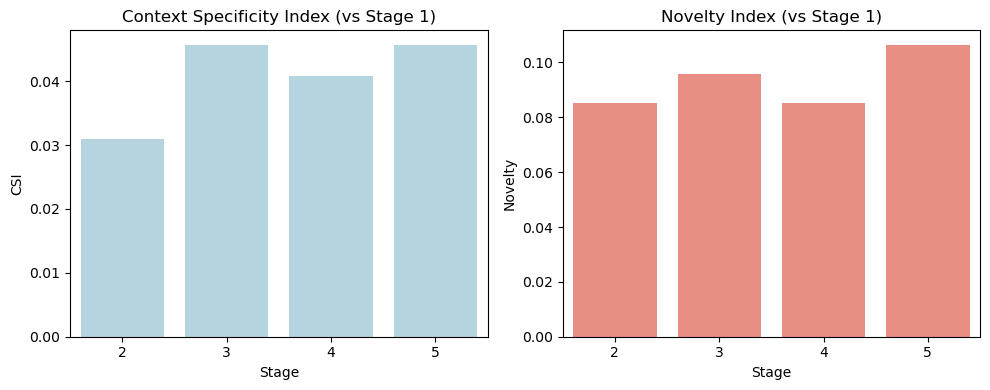

Max Shannon entropy: 6.700439718141092


C:\Users\gangliaguardian\AppData\Local\Temp\ipykernel_24068\1559527141.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stage_labels, y=rep_sizes, ax=axs[0], palette="Blues_d")
C:\Users\gangliaguardian\AppData\Local\Temp\ipykernel_24068\1559527141.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stage_labels, y=entropies, ax=axs[1], palette="Greens_d")


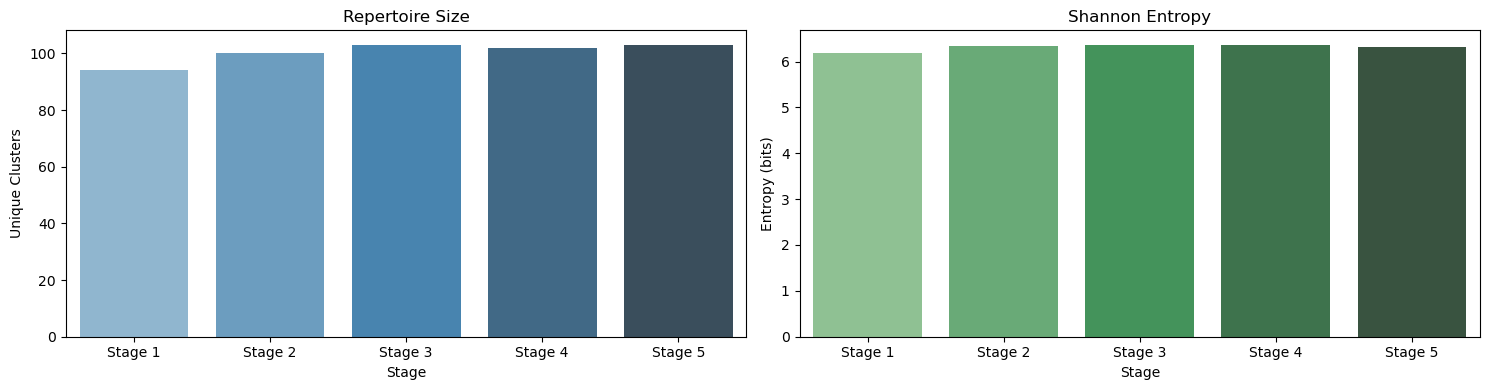

     Stage  Cosine Similarity  Jensen–Shannon Divergence
0  Stage 2             0.5575                     0.5419
1  Stage 3             0.6448                     0.5086
2  Stage 4             0.6535                     0.4914
3  Stage 5             0.4961                     0.4722


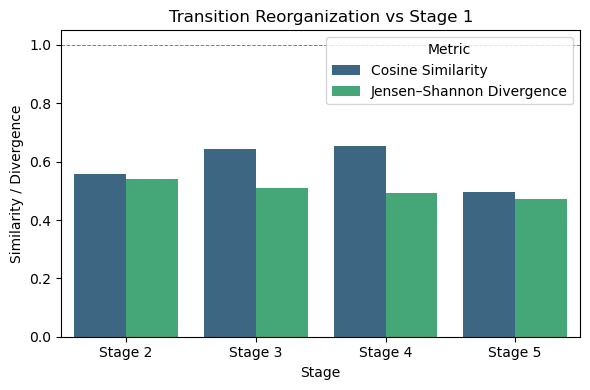

,Stage,Unique n-grams,Shared w/ Stage 1,New (vs Stage 1),Lost (vs Stage 1)
0,Stage 1,16003,16003,0,0
1,Stage 2,18377,2905,15472,13098
2,Stage 3,18371,3092,15279,12911
3,Stage 4,18180,3239,14941,12764
4,Stage 5,17352,3414,13938,12589


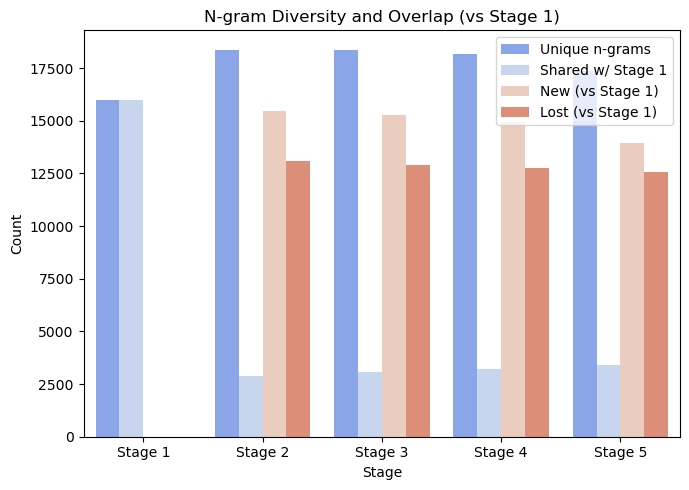

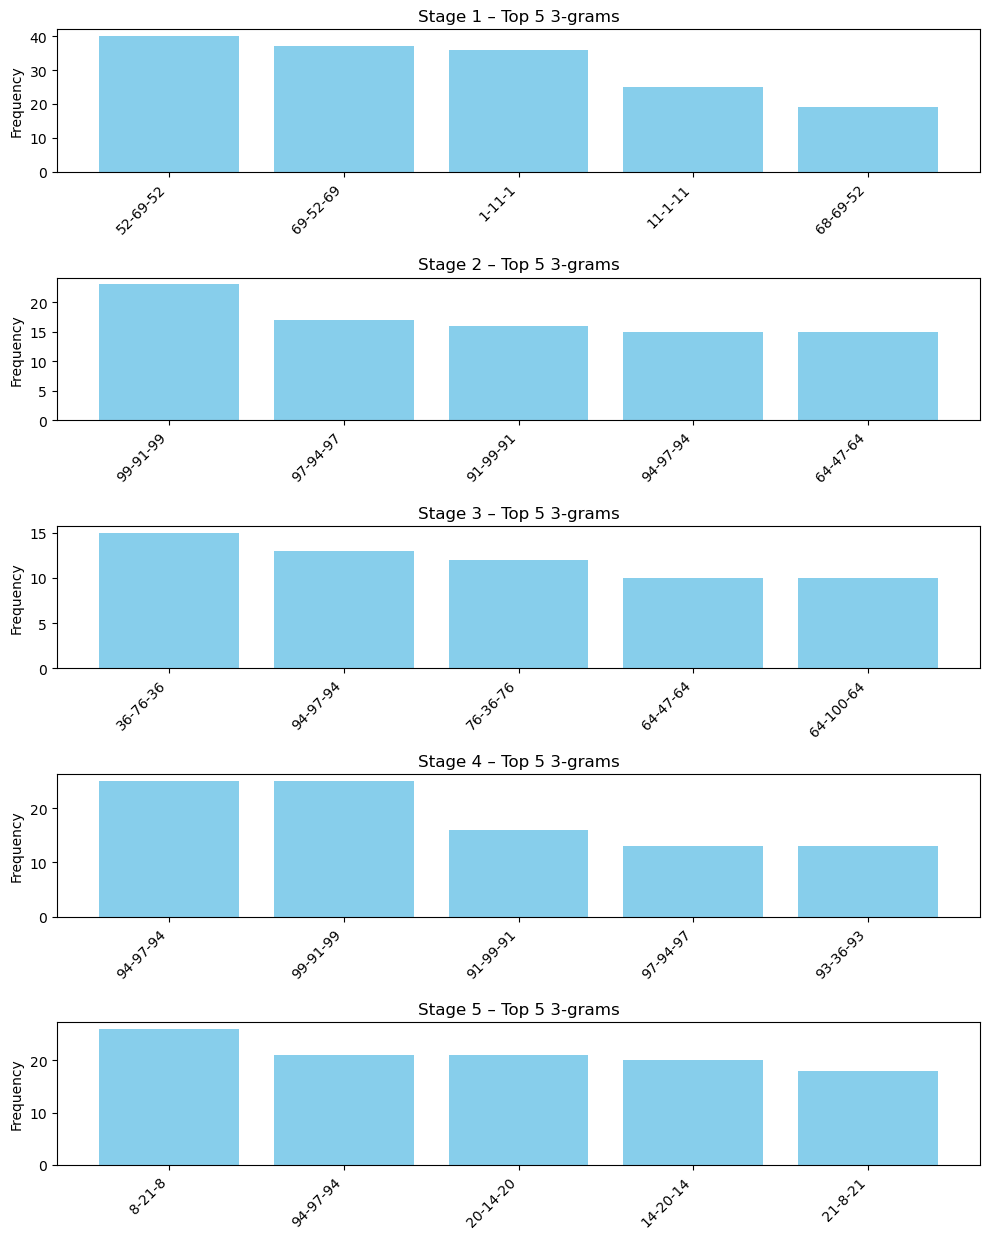

,Stage,Transition Entropy (bits)
0,Stage 1,4.324760
1,Stage 2,4.513415
2,Stage 3,4.400677
3,Stage 4,4.482185
4,Stage 5,4.314931


,Stage,Markov Entropy (bits)
0,Stage 1,4.684225
1,Stage 2,4.985772
2,Stage 3,4.968463
3,Stage 4,4.947539
4,Stage 5,4.692093


,Stage,Entropy Gap (Markov – Transition)
0,Stage 1,0.359465
1,Stage 2,0.472357
2,Stage 3,0.567786
3,Stage 4,0.465354
4,Stage 5,0.377162


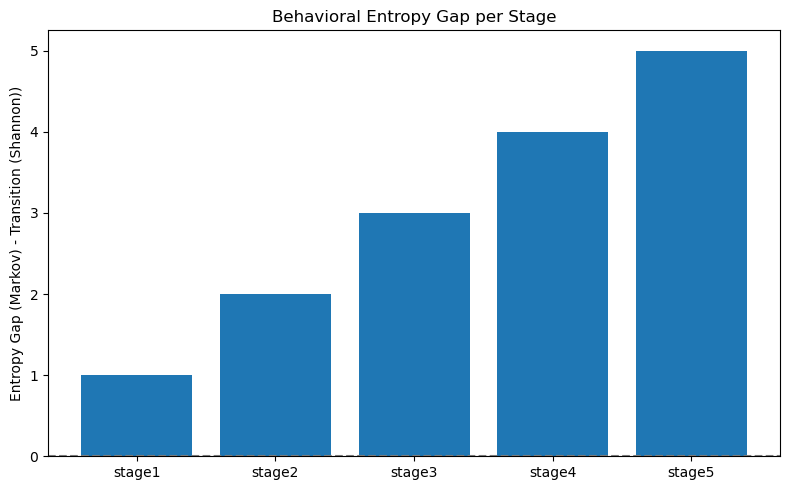

In [5]:
# Build a dictionary: stage → dataframe for that stage
stage_dfs = {
    stage: clusters_data.loc[clusters_data["stage"] == stage].reset_index(drop=True)
    for stage in sorted(clusters_data["stage"].unique())
}


# Make stage list once
stages = sorted(stage_dfs.keys())
stage_labels = [f"Stage {s}" for s in stages]

# Cluster sets for CSI + Novelty
stage_cluster_sets = {s: set(stage_dfs[s]["cluster"].unique()) for s in stages}

ref_stage = stages[0]
ref_clusters = stage_cluster_sets[ref_stage]

# -------------------- CSI + Novelty --------------------
csi_results = {s: compute_csi(stage_cluster_sets[s], ref_clusters) for s in stages if s != ref_stage}
novelty_results = {s: novelty_index(stage_cluster_sets[s], ref_clusters) for s in stages if s != ref_stage}

for metric_name, results in [
    (f"Context Specificity Index (relative to Stage {ref_stage})", csi_results),
    (f"Novelty Index (relative to Stage {ref_stage})", novelty_results),
]:
    print(metric_name)
    for s, val in results.items():
        print(f"Stage {s}: {val:.3f}")

plot_csi_novelty(list(csi_results.keys()), list(csi_results.values()), list(novelty_results.values()))


# -------------------- Shannon Entropy --------------------
rep_sizes = [stage_dfs[s]["cluster"].nunique() for s in stages]
entropies = [compute_shannon_entropy(stage_dfs[s]) for s in stages]

all_clusters = pd.concat(stage_dfs.values())["cluster"].unique()
n_clusters = len(all_clusters)
max_shannon_entropy = np.log2(n_clusters)

entropy_norm = [(e / max_shannon_entropy) * 100 for e in entropies]

print("Max Shannon entropy:", max_shannon_entropy)

plot_rep_entropy(stage_labels, rep_sizes, entropies)


# -------------------- Transition Similarity --------------------
all_clusters = sorted(all_clusters)
cluster_to_idx = {c: i for i, c in enumerate(all_clusters)}
n_clusters = len(all_clusters)

transition_vecs = {
    s: get_transition_distribution(stage_dfs[s], cluster_to_idx, n_clusters)
    for s in stages
}

baseline_vec = transition_vecs[ref_stage]

df_trans = pd.DataFrame([
    {
        "Stage": f"Stage {s}",
        "Cosine Similarity": 1 - cosine(baseline_vec, transition_vecs[s]),
        "Jensen–Shannon Divergence": jensenshannon(baseline_vec, transition_vecs[s], base=2)
    }
    for s in stages if s != ref_stage
])

print(df_trans.round(4))
plot_similarities(df_trans)


# -------------------- N-gram analysis --------------------
dfs = [stage_dfs[s] for s in stages]
ngram_results, count_dicts = analyze_sequence_diversity_by_stages(dfs, n=3, exclude_repeats=True)

display(ngram_results)
plot_sequence_diversity(ngram_results)
plot_top_ngrams_stagewise(count_dicts, top_n=5, n=3)


# -------------------- Transition Entropy --------------------
transition_entropies = {s: compute_transition_entropy(stage_dfs[s]) for s in stages}

df_transition_entropy = pd.DataFrame({
    "Stage": stage_labels,
    "Transition Entropy (bits)": [transition_entropies[s] for s in stages]
})
display(df_transition_entropy)


# -------------------- Markov Entropy + entropy gap --------------------
markov_entropies = {s: compute_markov_entropy(stage_dfs[s]) for s in stages}

df_markov = pd.DataFrame({
    "Stage": stage_labels,
    "Markov Entropy (bits)": [markov_entropies[s] for s in stages]
})
display(df_markov)

entropy_gaps = {s: markov_entropies[s] - transition_entropies[s] for s in stages}

df_entropy_gap = pd.DataFrame({
    "Stage": stage_labels,
    "Entropy Gap (Markov – Transition)": [entropy_gaps[s] for s in stages]
})
display(df_entropy_gap)

plot_entropy_gap(entropy_gaps)
